# 02 — Sand bed detection (bbox)

Detects the perturbation segment (sand walking) for every processed trial using a **point-in-rectangle test** against the sand bed coordinates measured on the CODAMOTION setup.

## Method

The sand bed corners are physical measurements stored in `config.BAC_SAND_CORNERS_MM` (taken on 07/05/2026):

```
A (front-left)   B (front-right)
      ┌──────────────┐
      │  SAND BED    │   ~4.4 m × 1.0 m
      └──────────────┘
D (rear-left)    C (rear-right)
```

For each frame, we compute the sacrum barycentre (mean of Dos01–04) in the XY plane and test whether it falls inside the rectangle (with a ±100 mm margin). The **longest continuous in-bbox segment** is taken as the perturbation.

## Why bbox, not PCA

An earlier version compared PCA (CRF-calibrated corridor) and bbox on 38 trials. Bbox won (validated on 15/05/2026):

| Method | Median entry/exit error vs CRF | IQR |
|---|---|---|
| **bbox** | **≈ 0 s** | **< 5 s** |
| PCA | −60 s | ±60 s (outliers ±200 s) |

PCA was abandoned because the percentile-based margin produced an overly wide corridor that captured most of the loop circuit. The full PCA-vs-bbox comparison is archived in `notebooks/archive/`.

## ⚠️ Time reference

`entry_t` and `exit_t` are in the **POST-CROP** time reference (i.e. starting from `crop_start_s`). To compare with the raw CRF timestamps, add `crop_start_s`.

## Inputs / Outputs

- **Input** : `data/processed/*.npz` (38 trials)
- **Output** : `outputs/tables/02_sand_detection.csv`


In [2]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Run detection on all trials

In [3]:
TRIALS = participants.list_trials_to_process()
rows = []

for participant, condition in TRIALS:
    try:
        npz = writer.load_processed(participant, condition)
    except FileNotFoundError:
        print(f"  ⚠️  {participant} / {condition}  → no .npz, skip")
        continue

    # Reconstruct sacrum XY (post-crop reference) from raw Dos markers stored in the .npz
    dos_stack = []
    for m in ('Dos01', 'Dos02', 'Dos03', 'Dos04'):
        key = f'raw_{m}'
        if key in npz:
            dos_stack.append(npz[key][:, :2])  # X, Y only
    if not dos_stack:
        print(f"  ⚠️  {participant} / {condition}  → no Dos markers, skip")
        continue
    sacrum_xy = np.mean(np.stack(dos_stack, axis=0), axis=0)

    # Bbox detection
    det = detection.detect_sand_by_bbox(sacrum_xy)

    # Trial metadata + CRF for comparison
    trial = participants.get_trial(participant, condition)
    crop_start = trial.crop_start_s if trial.crop_start_s is not None else 0.0

    # CRF is in RAW reference → convert detection to raw for comparison
    entry_raw = det['entry_t'] + crop_start if not np.isnan(det['entry_t']) else np.nan
    exit_raw  = det['exit_t']  + crop_start if not np.isnan(det['exit_t'])  else np.nan

    err_entry = entry_raw - trial.crf_entry_s if trial.crf_entry_s is not None else np.nan
    err_exit  = exit_raw  - trial.crf_exit_s  if trial.crf_exit_s  is not None else np.nan

    rows.append({
        'participant':     participant,
        'condition':       condition,
        'crop_start_s':    crop_start,
        'entry_postcrop':  round(det['entry_t'], 2) if not np.isnan(det['entry_t']) else np.nan,
        'exit_postcrop':   round(det['exit_t'], 2)  if not np.isnan(det['exit_t'])  else np.nan,
        'entry_raw':       round(entry_raw, 2) if not np.isnan(entry_raw) else np.nan,
        'exit_raw':        round(exit_raw, 2)  if not np.isnan(exit_raw)  else np.nan,
        'duration_s':      round(det['exit_t'] - det['entry_t'], 2) if not np.isnan(det['entry_t']) else np.nan,
        'n_segments':      det['n_segments'],
        'crf_entry_s':     trial.crf_entry_s,
        'crf_exit_s':      trial.crf_exit_s,
        'err_entry_s':     round(err_entry, 2) if not np.isnan(err_entry) else np.nan,
        'err_exit_s':      round(err_exit, 2)  if not np.isnan(err_exit)  else np.nan,
    })

df = pd.DataFrame(rows)
print(f"✅ {len(df)} trials processed")
df

✅ 38 trials processed


,participant,condition,crop_start_s,entry_postcrop,exit_postcrop,entry_raw,exit_raw,duration_s,n_segments,crf_entry_s,crf_exit_s,err_entry_s,err_exit_s
0,001CrMa,beatmove_adaptatif,60.00,193.36,197.54,253.36,257.54,4.18,1,253.00,257.00,0.36,0.54
1,001CrMa,silence,60.00,198.50,203.15,258.50,263.15,4.65,1,254.00,263.00,4.50,0.15
2,001CrMa,tempo_random,60.00,188.61,192.96,248.61,252.96,4.35,1,248.00,253.00,0.61,-0.04
3,002CrPa,beatmove_adaptatif,120.00,123.60,128.53,243.60,248.53,4.93,1,243.00,248.00,0.60,0.53
4,002CrPa,silence,60.00,217.43,222.38,277.43,282.38,4.96,1,277.00,282.00,0.43,0.38
5,002CrPa,tempo_random,60.00,182.78,185.66,242.78,245.66,2.88,2,242.00,247.00,0.78,-1.34
6,003BrLu,beatmove_adaptatif,60.00,180.83,184.74,240.83,244.74,3.91,1,238.00,244.00,2.83,0.74
7,003BrLu,silence,72.00,163.14,167.11,235.14,239.11,3.97,1,235.42,239.27,-0.28,-0.16
8,003BrLu,tempo_random,60.00,191.50,193.93,251.50,253.93,2.43,1,251.22,254.75,0.28,-0.82
9,004CaGe,beatmove_adaptatif,60.00,195.04,199.11,255.04,259.11,4.07,1,255.34,259.00,-0.30,0.11


## 2. Validation vs CRF (manual annotations)

In [4]:
valid = df.dropna(subset=['err_entry_s', 'err_exit_s'])

summary = pd.DataFrame({
    'metric':     ['err_entry_s', 'err_exit_s', 'duration_s'],
    'median':     [valid['err_entry_s'].median(),
                   valid['err_exit_s'].median(),
                   valid['duration_s'].median()],
    'iqr':        [valid['err_entry_s'].quantile(0.75) - valid['err_entry_s'].quantile(0.25),
                   valid['err_exit_s'].quantile(0.75) - valid['err_exit_s'].quantile(0.25),
                   valid['duration_s'].quantile(0.75) - valid['duration_s'].quantile(0.25)],
    'min':        [valid['err_entry_s'].min(), valid['err_exit_s'].min(), valid['duration_s'].min()],
    'max':        [valid['err_entry_s'].max(), valid['err_exit_s'].max(), valid['duration_s'].max()],
    'N':          [len(valid), len(valid), len(valid)],
})
summary

,metric,median,iqr,min,max,N
0,err_entry_s,0.14,1.13,-2.96,6.99,36
1,err_exit_s,-0.14,0.74,-13.78,0.94,36
2,duration_s,3.65,1.23,1.79,5.06,36


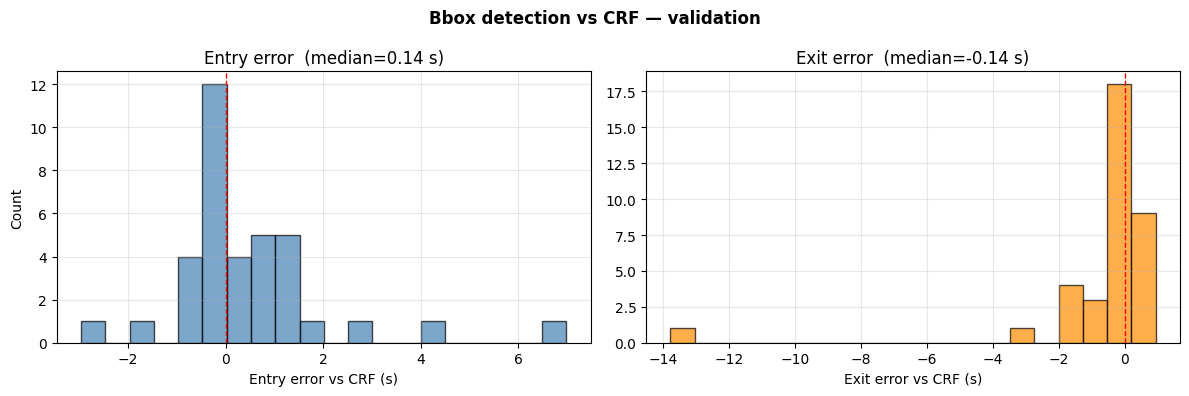

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(valid['err_entry_s'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Entry error vs CRF (s)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Entry error  (median={valid["err_entry_s"].median():.2f} s)')
axes[0].grid(alpha=0.3)

axes[1].hist(valid['err_exit_s'], bins=20, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Exit error vs CRF (s)')
axes[1].set_title(f'Exit error  (median={valid["err_exit_s"].median():.2f} s)')
axes[1].grid(alpha=0.3)

plt.suptitle('Bbox detection vs CRF — validation', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Per-trial QC: trials with large errors

In [6]:
ERR_THRESHOLD_S = 5.0

flagged = valid[(valid['err_entry_s'].abs() > ERR_THRESHOLD_S) |
                (valid['err_exit_s'].abs() > ERR_THRESHOLD_S)]
if len(flagged) == 0:
    print(f"✅ No trial with |error| > {ERR_THRESHOLD_S} s")
else:
    print(f"⚠️  {len(flagged)} trial(s) with |error| > {ERR_THRESHOLD_S} s — inspect manually")
    flagged[['participant', 'condition', 'err_entry_s', 'err_exit_s',
             'entry_raw', 'exit_raw', 'crf_entry_s', 'crf_exit_s']]

⚠️  1 trial(s) with |error| > 5.0 s — inspect manually


## 4. Export

In [7]:
out_dir = Path(paths.OUTPUTS_DIR) / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / '02_sand_detection.csv'
df.to_csv(out_csv, index=False)
print(f"✅ Exported: {out_csv}")

✅ Exported: C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\02_sand_detection.csv


## Notes

- `entry_t` / `exit_t` are in the post-crop time reference. Downstream notebooks (TDE, resilience) consume the post-crop version directly via `signals['time']`.
- The `entry_raw` / `exit_raw` columns are only used here for CRF comparison.
- Next step → `03_tde.ipynb` (TDE parameters per participant).